In [1]:
import torch
import torch.nn as nn
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

C:\Users\mmapa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

path1 = kagglehub.dataset_download("novandraanugrah/bitcoin-historical-datasets-2018-2024")

print("The dataset is downloaded to:", path1)

files1 = os.listdir(path1)
print("Folder contents:", files1)

100%|██████████| 19.4M/19.4M [00:01<00:00, 13.3MB/s]

Extracting files...


The dataset is downloaded to: C:\Users\mmapa\.cache\kagglehub\datasets\novandraanugrah\bitcoin-historical-datasets-2018-2024\versions\419
Folder contents: ['btc_15m_data_2018_to_2025.csv', 'btc_1d_data_2018_to_2025.csv', 'btc_1h_data_2018_to_2025.csv', 'btc_4h_data_2018_to_2025.csv']


In [4]:
bitcoin = pd.read_csv(os.path.join(path1, "btc_1d_data_2018_to_2025.csv"))

In [6]:
bitcoin.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [52]:
bitcoin.tail()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
2984,2026-03-04 00:00:00.000000 UTC,68338.01,68909.34,67857.61,68543.03,1831.35805,2026-03-04 23:59:59.999000 UTC,1.250343e+08,501562,913.83373,6.242022e+07,0
2985,2026-03-05 00:00:00.000000 UTC,72666.77,73306.82,72553.65,72589.46,1646.99020,2026-03-05 23:59:59.999000 UTC,1.199628e+08,504466,801.89199,5.841682e+07,0
2986,2026-03-06 00:00:00.000000 UTC,70891.02,71261.29,70344.03,71152.82,1651.57947,2026-03-06 23:59:59.999000 UTC,1.170352e+08,412082,864.12652,6.126500e+07,0
2987,2026-03-07 00:00:00.000000 UTC,68114.02,68394.09,68105.73,68251.56,914.93110,2026-03-07 23:59:59.999000 UTC,6.241224e+07,138700,463.00624,3.158072e+07,0
2988,2026-03-08 00:00:00.000000 UTC,67262.91,67481.96,67090.00,67329.41,1095.93084,2026-03-08 23:59:59.999000 UTC,7.372613e+07,142092,656.49587,4.415627e+07,0


In [47]:
bitcoin_close = bitcoin[['Close time', 'Close']]


In [48]:
bitcoin_close['Close time'] = pd.to_datetime(bitcoin_close['Close time'])
#move to datetime

C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\2044088185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_close['Close time'] = pd.to_datetime(bitcoin_close['Close time'])


In [49]:
bitcoin_close['Close time'] = bitcoin_close['Close time'].dt.date
# move to date

C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\4100889944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_close['Close time'] = bitcoin_close['Close time'].dt.date


In [50]:
bitcoin_close = bitcoin_close.set_index('Close time')
bitcoin_close.index = pd.to_datetime(bitcoin_close.index)# this is important, it fixes the index

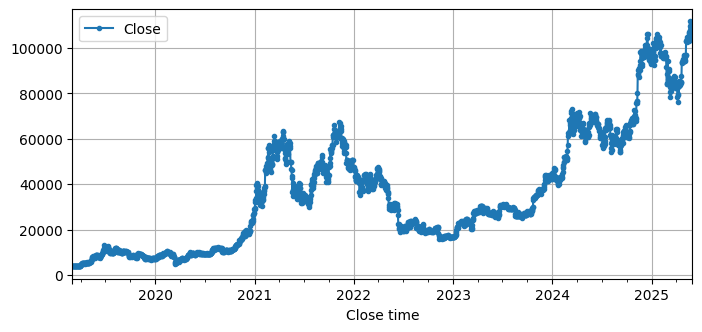

In [51]:
bitcoin_close["2019-03":"2025-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

In [59]:
from torch.utils.data import DataLoader
btc_train = torch.FloatTensor(bitcoin_close[['Close']]["2018-01":"2024-12"].values)
btc_valid = torch.FloatTensor(bitcoin_close[['Close']]["2025-01":"2025-06"].values)
btc_test = torch.FloatTensor(bitcoin_close[['Close']]["2025-07":].values)


In [61]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end] # wszystkie wartosci "okna"
        target = self.series[end] #wartosc po oknie
        return window, target

In [62]:
window_length = 56
train_set = TimeSeriesDataset(btc_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=False)
valid_set = TimeSeriesDataset(btc_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32, shuffle=False)
test_set = TimeSeriesDataset(btc_test, window_length)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)